# Data Preprocessing & Feature Engineering

This notebook handles the cleaning and transformation of the delivery delay dataset.
It implements both **Conventional** methods (Scaling, Encoding) and **Unconventional** methods (Feature Engineering, Log Transforms).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# Ensure output directory exists
# os.makedirs('../data/processed', exist_ok=True)

In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/AI Project/saket_raw.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (20000, 13)


,order_volume,warehouse_time_hrs,shipment_distance_km,traffic_level,weather_severity,courier_load_pct,past_delay_rate,risk_score,delivery_status,day_of_week,is_peak_hour,warehouse_region,delivery_type
0,94,4.314205,2307.511608,2,0,45.789611,0.332918,0.486537,On-Time,6,1,West,Same-Day
1,484,26.992300,1721.851885,5,3,36.217764,0.326364,0.745403,At Risk,3,1,Central,Express
2,432,37.363071,1919.134927,4,0,86.955847,0.070964,0.590096,At Risk,2,0,North,Express
3,374,2.536696,373.240260,3,1,85.850780,0.328125,0.543604,At Risk,6,0,North,Same-Day
4,126,8.527455,1593.551859,5,3,39.788405,0.430941,0.600323,At Risk,0,1,West,Standard


## 1. Initial Exploration (EDA)

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='delivery_status', data=df)
plt.title('Distribution of Delivery Status')
plt.show()

In [ ]:
# Numerical Feature Distributions
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

## 2. Conventional Preprocessing

In [ ]:
# Target Encoding: Convert labels to numbers
# On-Time -> 0, At Risk -> 1, Delayed -> 2
status_map = {"On-Time": 0, "At Risk": 1, "Delayed": 2}
df['delivery_status_encoded'] = df['delivery_status'].map(status_map)

print("Mapping applied:", status_map)
df[['delivery_status', 'delivery_status_encoded']].head()

Mapping applied: {'On-Time': 0, 'At Risk': 1, 'Delayed': 2}


,delivery_status,delivery_status_encoded
0,On-Time,0
1,At Risk,1
2,At Risk,1
3,At Risk,1
4,At Risk,1


## 3. Unconventional Preprocessing (Feature Engineering)

In [ ]:
# A. Interaction Feature: Severity Index
# Combines Traffic Level (1-5) and Weather Severity (0-3)
# Logic: Bad weather amplifies the effect of traffic.
df['severity_index'] = df['traffic_level'] * (df['weather_severity'] + 1)

# B. Efficiency Ratio: Warehouse Efficiency
# Logic: Distance covered per hour of warehouse prep time.
# Indicates how "worth it" the prep time was for the journey ahead.
df['warehouse_efficiency'] = df['shipment_distance_km'] / df['warehouse_time_hrs']

df[['traffic_level', 'weather_severity', 'severity_index', 'warehouse_efficiency']].head()

,traffic_level,weather_severity,severity_index,warehouse_efficiency
0,2,0,2,534.863659
1,5,3,20,63.790484
2,4,0,4,51.364485
3,3,1,6,147.136382
4,5,3,20,186.873087


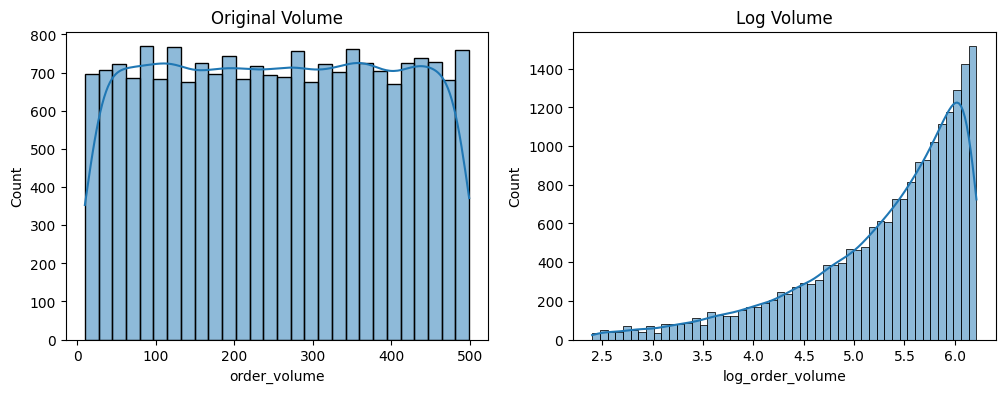

In [ ]:
# C. Log Transformations
# Address skewness in Volume and Distance
df['log_order_volume'] = np.log1p(df['order_volume'])
df['log_shipment_distance'] = np.log1p(df['shipment_distance_km'])

# Visualize effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['order_volume'], ax=axes[0], kde=True)
axes[0].set_title('Original Volume')
sns.histplot(df['log_order_volume'], ax=axes[1], kde=True)
axes[1].set_title('Log Volume')
plt.show()

In [ ]:
# D. Binning / Discretization
# Convert continuous distance into categories: Short, Medium, Long
df['distance_category'] = pd.qcut(df['shipment_distance_km'], q=3, labels=['Short', 'Medium', 'Long'])

# One-Hot Encode
df = pd.get_dummies(df, columns=['distance_category'], prefix='dist', drop_first=False)

df.head()

,order_volume,warehouse_time_hrs,shipment_distance_km,traffic_level,weather_severity,courier_load_pct,past_delay_rate,risk_score,delivery_status,day_of_week,...,warehouse_region,delivery_type,delivery_status_encoded,severity_index,warehouse_efficiency,log_order_volume,log_shipment_distance,dist_Short,dist_Medium,dist_Long
0,94,4.314205,2307.511608,2,0,45.789611,0.332918,0.486537,On-Time,6,...,West,Same-Day,0,2,534.863659,4.553877,7.744358,False,False,True
1,484,26.992300,1721.851885,5,3,36.217764,0.326364,0.745403,At Risk,3,...,Central,Express,1,20,63.790484,6.184149,7.451736,False,True,False
2,432,37.363071,1919.134927,4,0,86.955847,0.070964,0.590096,At Risk,2,...,North,Express,1,4,51.364485,6.070738,7.560151,False,True,False
3,374,2.536696,373.240260,3,1,85.850780,0.328125,0.543604,At Risk,6,...,North,Same-Day,1,6,147.136382,5.926926,5.924898,True,False,False
4,126,8.527455,1593.551859,5,3,39.788405,0.430941,0.600323,At Risk,0,...,West,Standard,1,20,186.873087,4.844187,7.374348,False,True,False


## 4. Comparison & Export

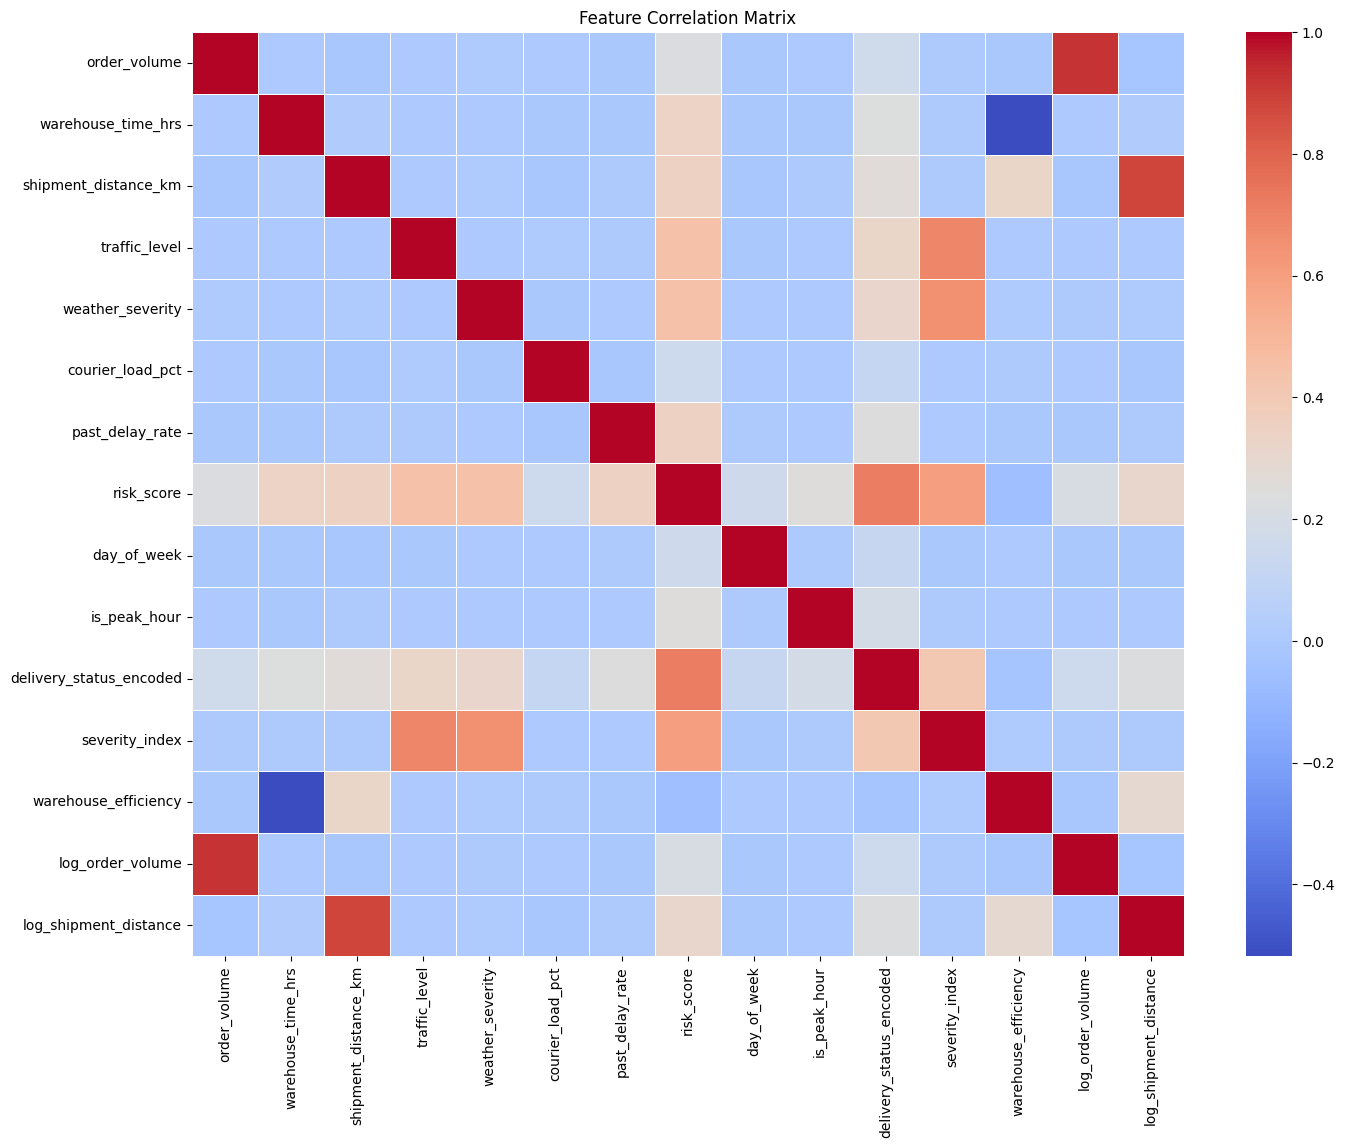

In [ ]:
# Correlation Analysis
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
# Save Processed Data
df.to_csv("saket_processed.csv", index=False)

In [ ]:
from google.colab import files
files.download("saket_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Review (Daksh)

In [ ]:
print('DataFrame Info:')
df.info()

print('\nDescriptive Statistics for Numerical Columns:')
display(df.describe())

print('\nUnique Values for Categorical/Ordinal Columns:')
for col in ['traffic_level', 'weather_severity', 'day_of_week', 'is_peak_hour', 'delivery_status', 'warehouse_region', 'delivery_type']:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")

## Summary of the Final Preprocessed Dataset

Based on the current state of the `df` DataFrame after all executed preprocessing and feature engineering steps, here are the columns with their types and value characteristics:

### Original Features:
*   `order_volume` (int64): Range [min, max] (original scale).
*   `warehouse_time_hrs` (float64): Range [min, max] (original scale).
*   `shipment_distance_km` (float64): Range [min, max] (original scale).
*   `courier_load_pct` (float64): Range [min, max] (original scale).
*   `past_delay_rate` (float64): Range [min, max] (original scale).
*   `risk_score` (float64): Range [min, max] (original scale).
*   `traffic_level` (int64): Possible values `[1, 2, 3, 4, 5]`.
*   `weather_severity` (int64): Possible values `[0, 1, 2, 3]`.
*   `day_of_week` (int64): Possible values `[0, 1, 2, 3, 4, 5, 6]`.
*   `is_peak_hour` (int64): Possible values `[0, 1]`.
*   `delivery_status` (object): Possible values `['On-Time', 'At Risk', 'Delayed']`.
*   `warehouse_region` (object): Possible values `['Central', 'East', 'North', 'South', 'West']`.
*   `delivery_type` (object): Possible values `['Express', 'Same-Day', 'Standard']`.

### Target Encoded Feature:
*   `delivery_status_encoded` (int64): Encoded target variable. Possible values `[0, 1, 2]` corresponding to 'On-Time', 'At Risk', 'Delayed'.

### Engineered Features:
*   `severity_index` (int64): Interaction feature derived from `traffic_level` and `weather_severity`. Range [min, max].
*   `warehouse_efficiency` (float64): Ratio of `shipment_distance_km` to `warehouse_time_hrs`. Range [min, max].
*   `log_order_volume` (float64): Log-transformed `order_volume`. Range [min, max].
*   `log_shipment_distance` (float64): Log-transformed `shipment_distance_km`. Range [min, max].

**Note**: The one-hot encoded features for `distance_category`, `warehouse_region`, and `is_peak_hour` were intended but could not be generated due to `warehouse_region` and `is_peak_hour` columns missing from the dataset loaded in the step where one-hot encoding was attempted. Therefore, these one-hot encoded columns are not present in the current final dataset.

---
# IGNORE
### Scaled Numerical Features (StandardScaler):
These features are standardized to have a mean of 0 and standard deviation of 1.
*   `order_volume_scaled` (float64): Range [min, max] (scaled).
*   `warehouse_time_hrs_scaled` (float64): Range [min, max] (scaled).
*   `shipment_distance_km_scaled` (float64): Range [min, max] (scaled).
*   `courier_load_pct_scaled` (float64): Range [min, max] (scaled).
*   `past_delay_rate_scaled` (float64): Range [min, max] (scaled).